In [46]:
from keras.models import load_model
from pathlib import Path
import joblib
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error
import matplotlib.pyplot as plt


In [47]:
scalar = joblib.load(r'E:\NYISO_Project\dataset\scaler.joblib')
X_val = np.load(r'E:\NYISO_Project\dataset\X_val.npy')
y_val = np.load(r'E:\NYISO_Project\dataset\y_val.npy')
X_train = np.load(r'E:\NYISO_Project\dataset\X_train.npy')
y_train = np.load(r'E:\NYISO_Project\dataset\y_train.npy')

In [48]:
model_lstm = load_model(r'E:\NYISO_Project\models\load_forecasting_lstm.keras')
model_gru = load_model(r'E:\NYISO_Project\models\load_forecasting_gru.keras')

In [49]:
model_lstm.summary()
model_gru.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_6 (LSTM)                   │ (None, 24, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 24, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_7 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 156,101 (609.77 KB)

 Trainable params: 52,033 (203.25 KB)

 Non-trainable params: 0 (0.00 B)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_4 (GRU)                     │ (None, 24, 64)         │        12,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 24, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_5 (GRU)                     │ (None, 64)             │        24,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 119,813 (468.02 KB)

 Trainable params: 39,937 (156.00 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 79,876 (312.02 KB)

##### LSTM Inference

In [50]:
actual_load = scalar.inverse_transform(y_val.reshape(-1, 1))
prediction_scaled_lstm = model_lstm.predict(X_val)
predicted_load_lstm = scalar.inverse_transform(prediction_scaled_lstm)

273/273 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


In [51]:
rmse_lstm = np.sqrt(mean_squared_error(actual_load, predicted_load_lstm))
mape_lstm = mean_absolute_percentage_error(actual_load, predicted_load_lstm)*100

In [52]:
print("\n--- Final 2025 Validation Results for LSTM Model ---")
print(f"MAPE (Mean Absolute Percentage Error): {mape_lstm:.2f}%")
print(f"RMSE (Root Mean Square Error): {rmse_lstm:.2f} MW")


--- Final 2025 Validation Results for LSTM Model ---
MAPE (Mean Absolute Percentage Error): 0.85%
RMSE (Root Mean Square Error): 195.51 MW


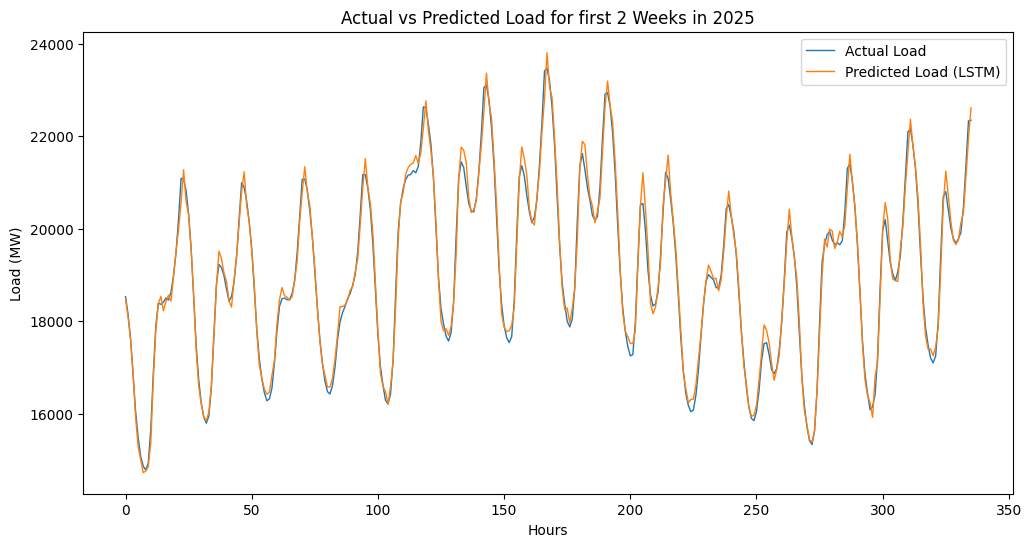

In [53]:
# Plotting actual vs predicted load for 2 weeks in 2025
hours_to_plot = 24 * 14  # 2 weeks of hourly data
plt.figure(figsize=(12, 6))
plt.plot(actual_load[:hours_to_plot], label='Actual Load', linewidth=1)
plt.plot(predicted_load_lstm[:hours_to_plot], label='Predicted Load (LSTM)', linewidth=1)
plt.xlabel('Hours')
plt.ylabel('Load (MW)')
plt.title('Actual vs Predicted Load for first 2 Weeks in 2025')
plt.legend()
plt.show()

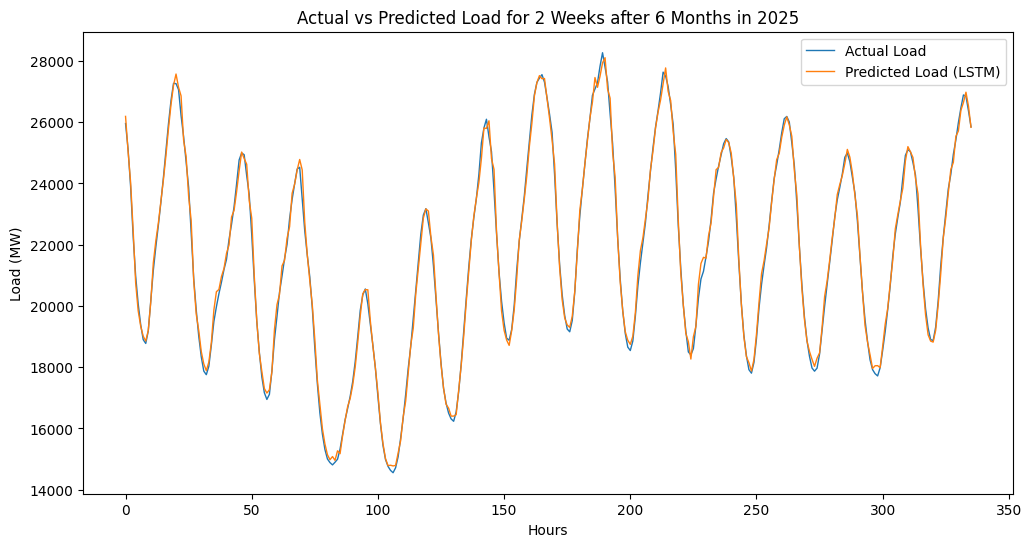

In [60]:
# Plotting prediction for two weeks after 6 months of 2025
start_hour = 24 * 30 * 6  # Starting after 6 months
plt.figure(figsize=(12, 6))
plt.plot(actual_load[start_hour:start_hour + hours_to_plot], label='Actual Load', linewidth=1)
plt.plot(predicted_load_lstm[start_hour:start_hour + hours_to_plot], label='Predicted Load (LSTM)', linewidth=1)
plt.xlabel('Hours')
plt.ylabel('Load (MW)')
plt.title('Actual vs Predicted Load for 2 Weeks after 6 Months in 2025')
plt.legend()

##### GRU Inference

In [55]:
prediction_scaled_gru = model_gru.predict(X_val)
predicted_load_gru = scalar.inverse_transform(prediction_scaled_gru)

273/273 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


In [56]:
rmse_gru = np.sqrt(mean_squared_error(actual_load, predicted_load_gru))
mape_gru = mean_absolute_percentage_error(actual_load, predicted_load_gru)*100

In [57]:
print("\n--- Final 2025 Validation Results for GRU Model ---")
print(f"MAPE (Mean Absolute Percentage Error): {mape_gru:.2f}%")
print(f"RMSE (Root Mean Square Error): {rmse_gru:.2f} MW")


--- Final 2025 Validation Results for GRU Model ---
MAPE (Mean Absolute Percentage Error): 1.40%
RMSE (Root Mean Square Error): 329.38 MW


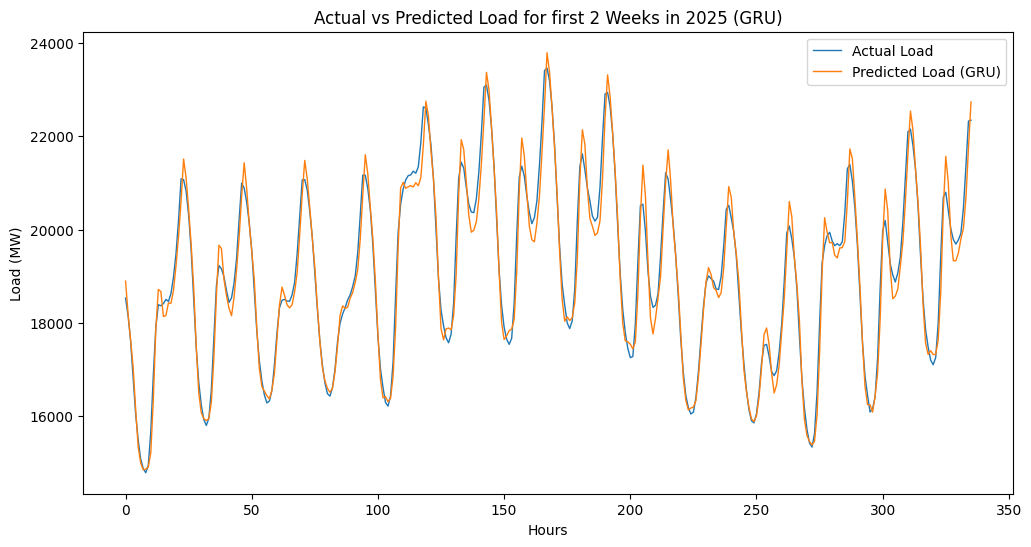

In [58]:
# Plotting actual vs predicted load for 2 weeks in 2025 for GRU
plt.figure(figsize=(12, 6))
plt.plot(actual_load[:hours_to_plot], label='Actual Load', linewidth=1)
plt.plot(predicted_load_gru[:hours_to_plot], label='Predicted Load (GRU)', linewidth=1)
plt.xlabel('Hours')
plt.ylabel('Load (MW)')
plt.title('Actual vs Predicted Load for first 2 Weeks in 2025 (GRU)')
plt.legend()


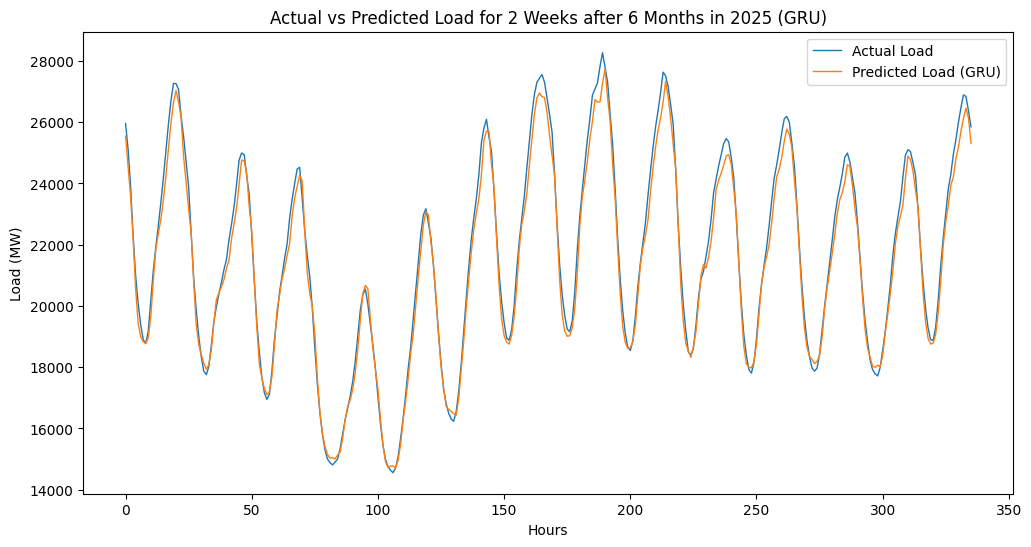

In [59]:
# Plotting actual vs predicted load for 2 weeks after 6 months in 2025 for GRU
plt.figure(figsize=(12,6))
plt.plot(actual_load[start_hour:start_hour + hours_to_plot], label='Actual Load', linewidth=1)
plt.plot(predicted_load_gru[start_hour:start_hour + hours_to_plot], label='Predicted Load (GRU)', linewidth=1)
plt.xlabel('Hours')
plt.ylabel('Load (MW)')
plt.title('Actual vs Predicted Load for 2 Weeks after 6 Months in 2025 (GRU)')
plt.legend()